In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs 

# Setting random seed for reproducibility 
np.random.seed(42)

In [2]:
n_samples_1 = 25 
n_samples_2 = 375 
centers = [(0,0),(2,2)]
cluster_std = [1.5,1.5]



In [3]:
X,y = make_blobs(n_samples=[n_samples_1,n_samples_2],
                 centers=centers, cluster_std=cluster_std, random_state=0)

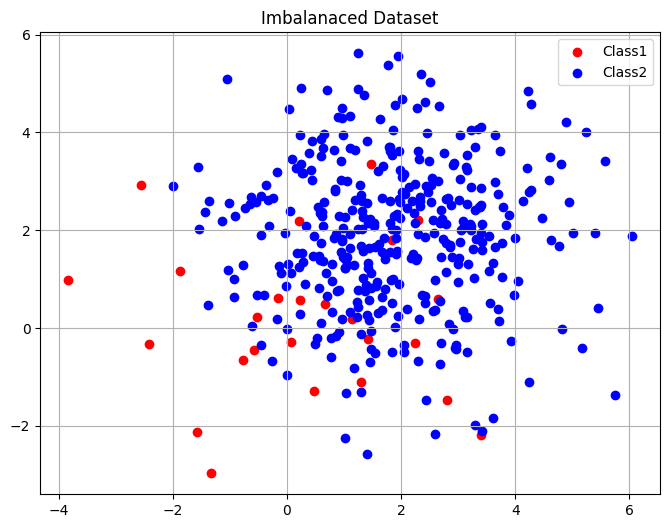

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(X[y==0][:, 0],X[y==0][:,1], color='red', label='Class1')
plt.scatter(X[y==1][:, 0],X[y==1][:,1], color='blue', label='Class2')
plt.title("Imbalanaced Dataset")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import classification_report, roc_auc_score,roc_curve 
from sklearn.model_selection import train_test_split as tts 


In [6]:
X_train,X_test,y_train,y_test = tts(X,y,test_size=0.3,random_state=42)


In [7]:
clf1 = LogisticRegression()
clf1.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

clf report               precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.96      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.98      0.64      0.71       120
weighted avg       0.96      0.96      0.95       120

ROC-AUC Score:  0.9557522123893806


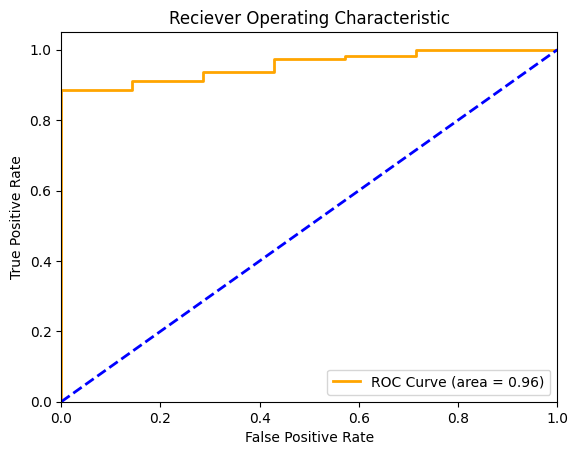

In [8]:
y_pred = clf1.predict(X_test)
y_prob = clf1.predict_proba(X_test)[:,1]


# classification report 
print("clf report", classification_report(y_test,y_pred))

print("ROC-AUC Score: ", roc_auc_score(y_test,y_prob))

# plotting ROC-AUC curve

fpr, tpr, _ = roc_curve(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr, color='orange', lw=2,label= 'ROC Curve (area = %0.2f)' % roc_auc_score(y_test,y_prob))
plt.plot([0,1],[0,1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.title("Reciever Operating Characteristic")
plt.show()

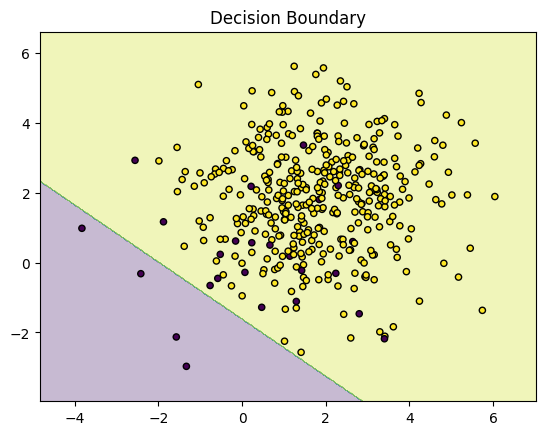

In [9]:
def plot_decision_boundaries(X,y,model):
    plot_step = 0.02
    X_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min , y_max = X[:,1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(X_min,x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx,yy,Z, alpha=0.3)
    plt.scatter(X[:,0],X[:,1], c=y, edgecolors='k', s=20)
    plt.title("Decision Boundary")
    plt.show()
    

plot_decision_boundaries(X,y,clf1)

In [10]:
from imblearn.under_sampling import RandomUnderSampler

X_train, X_test, y_train, y_test = tts(X,y, test_size=0.2, random_state=42 )

In [11]:
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)


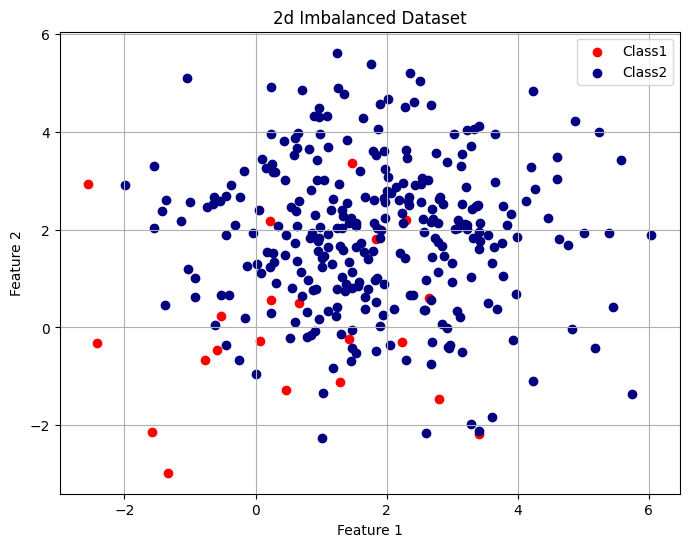

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(X_train[y_train==0][:, 0],X_train[y_train==0][:, 1], color='red', label='Class1')
plt.scatter(X_train[y_train==1][:, 0],X_train[y_train==1][:, 1], color='navy', label='Class2')
plt.title('2d Imbalanced Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


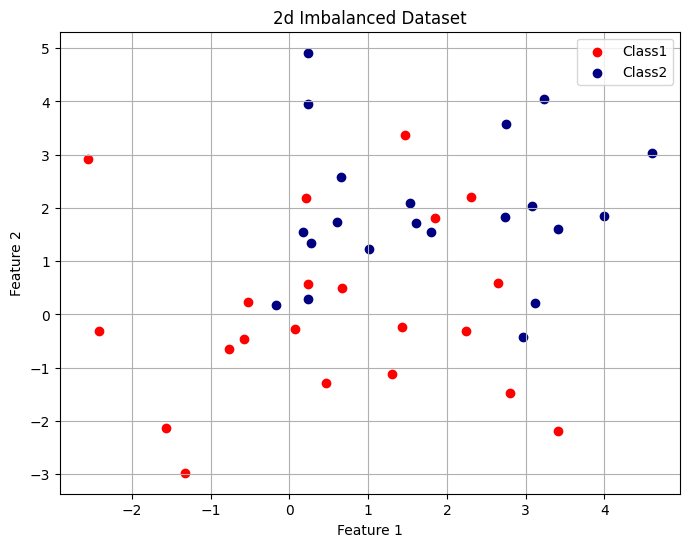

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(X_resampled[y_resampled==0][:, 0],X_resampled[y_resampled==0][:, 1], color='red', label='Class1')
plt.scatter(X_resampled[y_resampled==1][:, 0],X_resampled[y_resampled==1][:, 1], color='navy', label='Class2')
plt.title('2d Imbalanced Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
X_train.shape

(320, 2)

In [15]:
X_resampled.shape

(42, 2)

In [16]:
import pandas as pd 

pd.Series(y_train).value_counts()

1    299
0     21
Name: count, dtype: int64

In [17]:
pd.Series(y_resampled).value_counts()

0    21
1    21
Name: count, dtype: int64

In [18]:
clf2 = RandomForestClassifier()

clf report               precision    recall  f1-score   support

           0       0.12      0.75      0.20         4
           1       0.98      0.70      0.82        76

    accuracy                           0.70        80
   macro avg       0.55      0.72      0.51        80
weighted avg       0.94      0.70      0.78        80

ROC-AUC Score:  0.7335526315789473


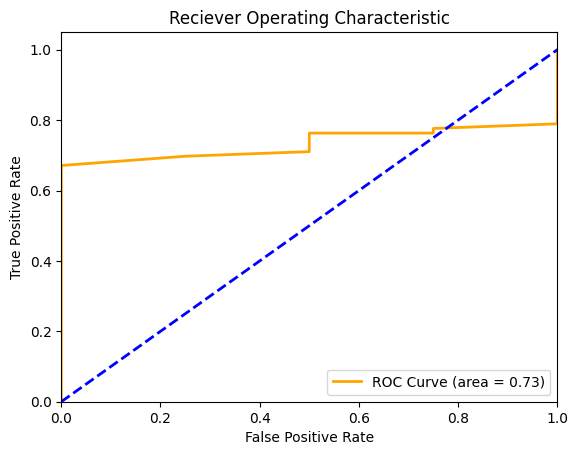

In [19]:
clf2.fit(X_resampled,y_resampled)

y_pred = clf2.predict(X_test)
y_prob = clf2.predict_proba(X_test)[:, 1]

print("clf report", classification_report(y_test,y_pred))

print("ROC-AUC Score: ", roc_auc_score(y_test,y_prob))

# plotting ROC-AUC curve

fpr, tpr, _ = roc_curve(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr, color='orange', lw=2,label= 'ROC Curve (area = %0.2f)' % roc_auc_score(y_test,y_prob))
plt.plot([0,1],[0,1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.title("Reciever Operating Characteristic")
plt.show()

In [20]:
clf3 = LogisticRegression()

clf report               precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC-AUC Score:  0.9375


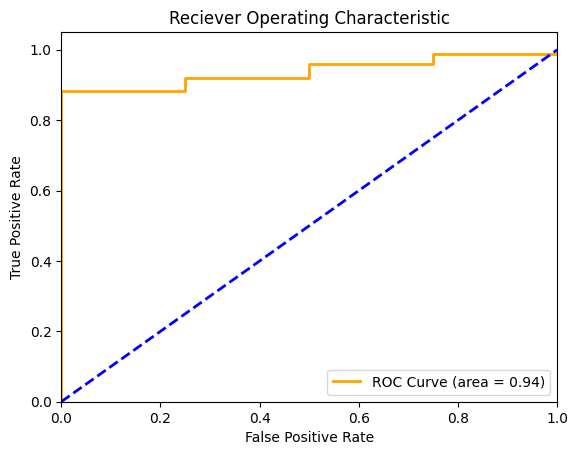

In [21]:
clf3.fit(X_resampled,y_resampled)

y_pred = clf3.predict(X_test)
y_prob = clf3.predict_proba(X_test)[:, 1]

print("clf report", classification_report(y_test,y_pred))

print("ROC-AUC Score: ", roc_auc_score(y_test,y_prob))

# plotting ROC-AUC curve

fpr, tpr, _ = roc_curve(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr, color='orange', lw=2,label= 'ROC Curve (area = %0.2f)' % roc_auc_score(y_test,y_prob))
plt.plot([0,1],[0,1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.title("Reciever Operating Characteristic")
plt.show()

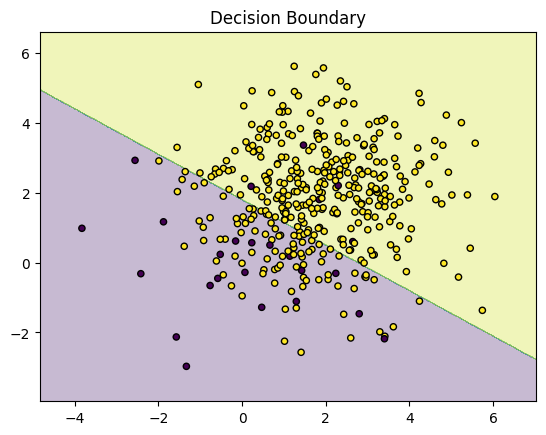

In [22]:
plot_decision_boundaries(X,y,clf3)

### Over Sampling


In [23]:
from imblearn.over_sampling import RandomOverSampler 



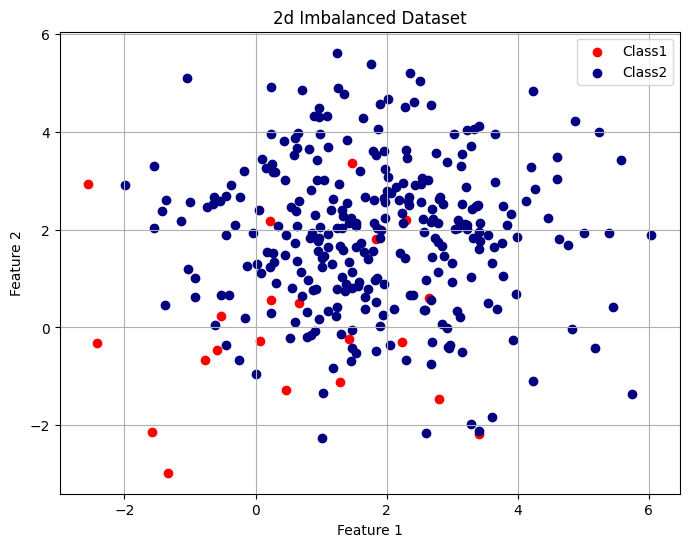

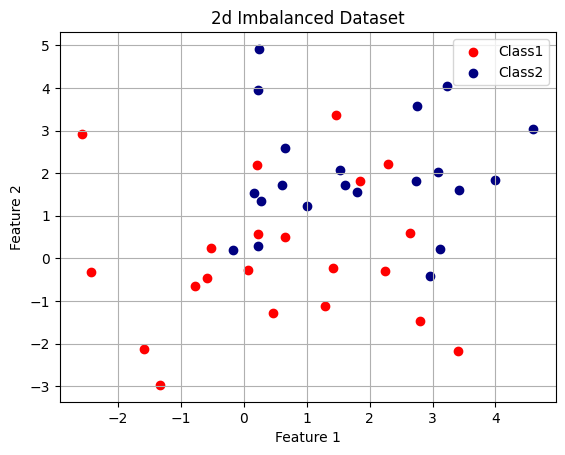

In [29]:
X_train, X_test, y_train, y_test = tts(X,y, test_size=0.2, random_state=42 )

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

plt.figure(figsize=(8,6))
plt.scatter(X_train[y_train==0][:, 0],X_train[y_train==0][:, 1], color='red', label='Class1')
plt.scatter(X_train[y_train==1][:, 0],X_train[y_train==1][:, 1], color='navy', label='Class2')
plt.title('2d Imbalanced Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()
X_train, X_test, y_train, y_test = tts(X,y, test_size=0.2, random_state=42 )

plt.scatter(X_resampled[y_resampled==0][:, 0],X_resampled[y_resampled==0][:, 1], color='red', label='Class1')
plt.scatter(X_resampled[y_resampled==1][:, 0],X_resampled[y_resampled==1][:, 1], color='navy', label='Class2')
plt.title('2d Imbalanced Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
X_train.shape, X_resampled.shape 

((320, 2), (598, 2))

In [26]:
pd.Series(y_train).value_counts(),pd.Series(y_resampled).value_counts()

(1    299
 0     21
 Name: count, dtype: int64,
 1    299
 0    299
 Name: count, dtype: int64)

clf report               precision    recall  f1-score   support

           0       0.18      1.00      0.31         4
           1       1.00      0.76      0.87        76

    accuracy                           0.78        80
   macro avg       0.59      0.88      0.59        80
weighted avg       0.96      0.78      0.84        80

ROC-AUC Score:  0.950657894736842


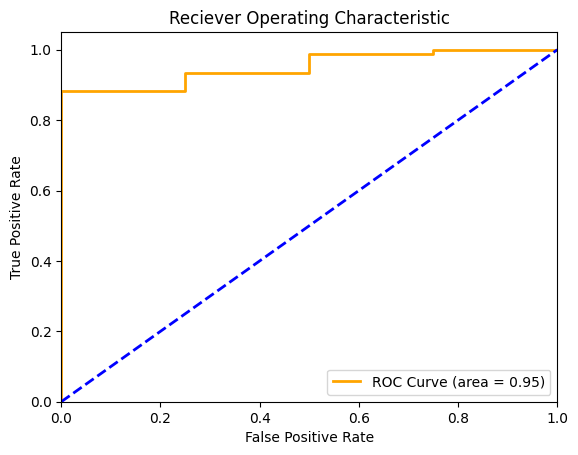

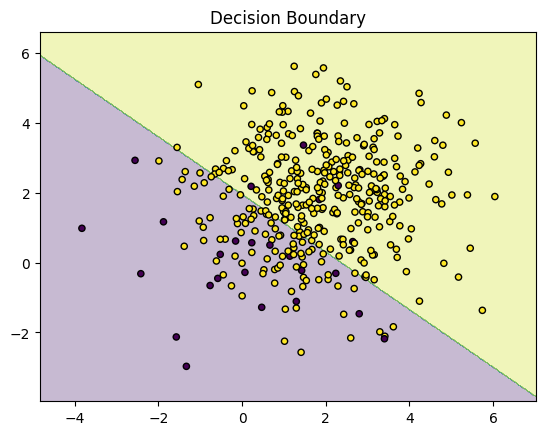

In [28]:
clf_ros = LogisticRegression()
clf_ros.fit(X_resampled,y_resampled)

y_pred = clf_ros.predict(X_test)
y_prob = clf_ros.predict_proba(X_test)[:,1]

print("clf report", classification_report(y_test,y_pred))

print("ROC-AUC Score: ", roc_auc_score(y_test,y_prob))

# plotting ROC-AUC curve

fpr, tpr, _ = roc_curve(y_test,y_prob)
plt.figure()
plt.plot(fpr,tpr, color='orange', lw=2,label= 'ROC Curve (area = %0.2f)' % roc_auc_score(y_test,y_prob))
plt.plot([0,1],[0,1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.title("Reciever Operating Characteristic")
plt.show()

plot_decision_boundaries(X,y,clf_ros)
